In [1]:
!python --version

Python 3.13.7


The system cannot find the path specified.


In [1]:
import numpy as np
from numpy.typing import NDArray
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression

In [2]:
# root traits - total root length (TRL), average root diameter (ARD) and root surface area (RSA) and root volume (RV)
# hyphal traits - hyphal diameter (HD), hyphal branching angle (HBA) and internodal hyphal length (IHL)

In [3]:
ROOT_COLOURS = 
ROOT_TRAITS = ("TRL", "AVD", "RSA", "RV")

SyntaxError: invalid syntax (2088965821.py, line 1)

In [4]:
# linear regression
model = LinearRegression()

In [5]:
model.fit(x.reshape(-1, 1), x + np.random.normal(loc=0, scale=0.5, size=x.shape))

NameError: name 'x' is not defined

In [72]:
print(model.coef_, model.intercept_)

[0.9846602] 0.12239173482412369


In [143]:
pearsonr(x, np.random.normal(loc=0, scale=0.75, size=x.shape))

PearsonRResult(statistic=np.float64(-0.006637643400081607), pvalue=np.float64(0.9477419650541223))

In [184]:
np.random.rand(100) - 0.5

array([ 0.14072615,  0.22758239,  0.3510054 , -0.24751717,  0.47238371,
        0.04033214, -0.35660262, -0.40986777, -0.07087266,  0.1732217 ,
       -0.45960557,  0.30674563, -0.48951704,  0.06336954, -0.14704065,
        0.26127836, -0.35471805,  0.22964973,  0.25621155, -0.22057217,
        0.33415774,  0.24379662,  0.29292953,  0.01955619,  0.21529136,
        0.45597904, -0.27240936, -0.25945785, -0.49648785, -0.0256268 ,
       -0.09863039, -0.14162997,  0.37811333, -0.45285525,  0.24792862,
        0.04434566,  0.27206589, -0.21660397,  0.09674308,  0.04487723,
        0.40374325,  0.47382427,  0.37919831, -0.17255314, -0.19367249,
       -0.3224707 , -0.13250535,  0.2497293 ,  0.38964589,  0.41872859,
        0.29982663, -0.40719454,  0.22114464, -0.31011027,  0.43565998,
       -0.11207446, -0.30531506,  0.02679372,  0.37333133, -0.48840361,
       -0.24635399, -0.00877731,  0.3226351 ,  0.41500715,  0.05151675,
       -0.36434484, -0.27060219, -0.02424477, -0.01528146,  0.22

In [6]:
def plot_scatters_and_regression_results(ax: plt.Axes, x: NDArray[np.integer|np.floating], centre: float, _range: float,
                                         title: str, markersize:int, colours: tuple[str] = ("teal", "purple", "crimson", "orange", "green", "blue")) -> plt.Axes:
    """
    """

    x.sort() # sort the xs so the plot doesn't look like a mess of haphazard fragments
    ax.set_title(title)
    # ax.plot(x, x, c="black", linestyle="dotted") # plot the diagonal
    for i, col in enumerate(colours):
        
        _y = x + np.sin(x) + np.random.normal(loc=centre, scale=_range, size=x.shape) # bogus measurements
        ax.scatter(x=x, y=_y, s=markersize, c=col, edgecolor="black")
        
        lm = LinearRegression().fit(x.reshape(-1, 1), _y) # fit the model on bogus measurements
        _y_pred = lm.coef_ * x + lm.intercept_  # predicted measurements based on parameters inferred from the bogus measurements
        corr = pearsonr(x, _y_pred + np.random.rand(*_y_pred.shape))[0] # add a bit of jitter and calculate the correlation between the bogus measurements and predictions
        ax.plot(x, _y_pred, color=col, label=f"$R^2 (M_{i})={corr:.4f}$", marker="none")
        ax.legend(loc="upper left")

    return ax

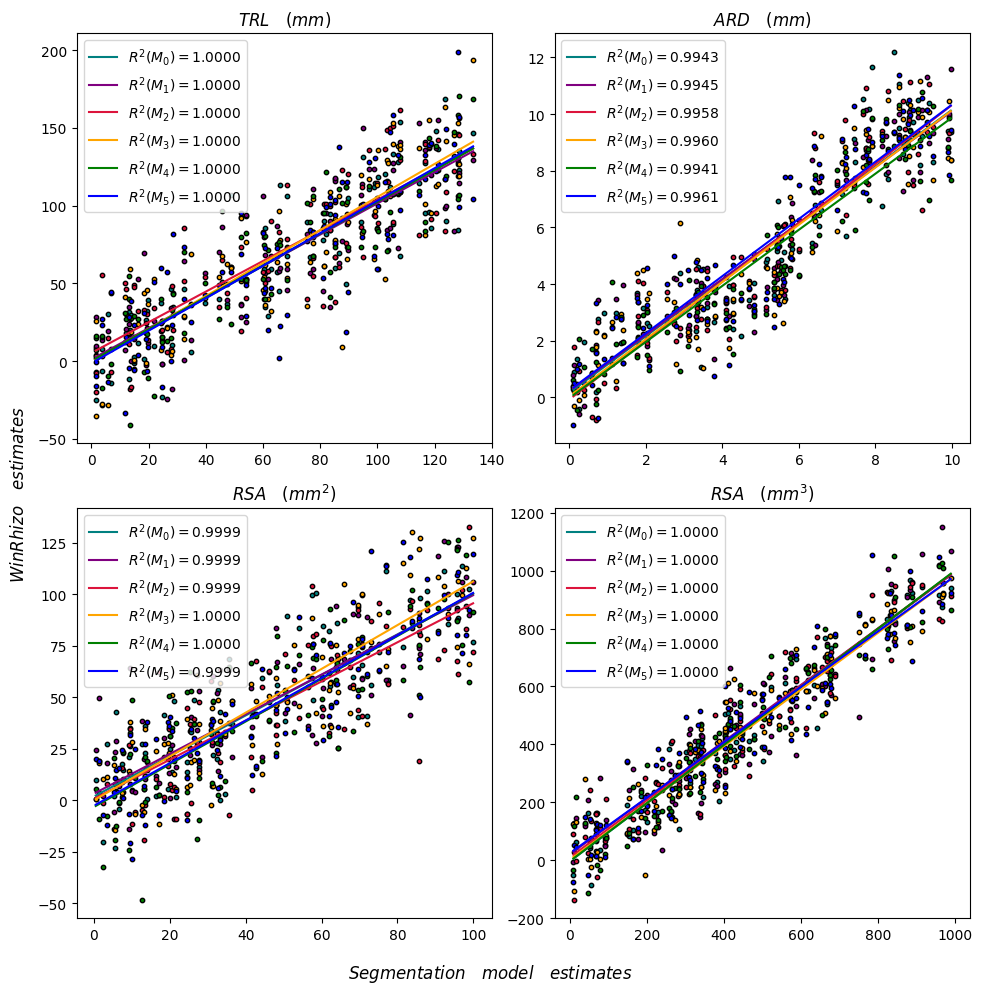

In [10]:
fig, axes = plt.subplots(ncols=2, nrows=2)
axis_0, axis_1, axis_2, axis_3 = axes.flatten()
fig.set_size_inches(10, 10)

plot_scatters_and_regression_results(ax=axis_0, x=np.random.rand(100) * 134, centre=0, _range=24, title=r"$TRL\hspace{1}(mm)$", markersize=10)
plot_scatters_and_regression_results(ax=axis_1, x=np.random.rand(100) * 10, centre=0, _range=0.975, title=r"$ARD\hspace{1}(mm)$", markersize=10)
plot_scatters_and_regression_results(ax=axis_2, x=np.random.rand(100) * 100, centre=0, _range=19.6, title=r"$RSA\hspace{1}(mm^2)$", markersize=10)
plot_scatters_and_regression_results(ax=axis_3, x=np.random.rand(100) * 1000, centre=0, _range=89, title=r"$RSA\hspace{1}(mm^3)$", markersize=10)

fig.supxlabel(r"$Segmentation\hspace{1}model\hspace{1}estimates$")
fig.supylabel(r"$WinRhizo\hspace{1}estimates$")

plt.tight_layout()
plt.show()
# plt.savefig(r"../../plots/rtestimates.png", dpi=400)